# Segment-Level Revenue Forecasting

We forecast monthly accepted-quote revenue for each customer segment,
6 months ahead, using a lag-feature + gradient-boosting approach (this
environment doesn't have `statsmodels`/`prophet` available, so instead
of ARIMA/exponential smoothing we frame forecasting as a supervised
learning problem on lag and calendar features -- a common,
production-friendly alternative that also lets the model share
statistical strength across segments instead of fitting four isolated
univariate models).

Forecasts are produced **recursively**: each month's prediction feeds
the lag features for the next month, exactly as it would need to in
production where future actuals aren't available yet.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
import sys, os

sys.path.append(os.getcwd())
from config import DATA_DIR, FIG_DIR, CATEGORICAL, INK, SEGMENT_ORDER, RANDOM_SEED, set_style

set_style()
FIG_SUBDIR = os.path.join(FIG_DIR, "06_forecast")
os.makedirs(FIG_SUBDIR, exist_ok=True)

monthly = pd.read_csv(os.path.join(DATA_DIR, "monthly_revenue.csv"), parse_dates=["month"])
# drop the current, still-in-progress calendar month
last_complete_month = monthly["month"].max().replace(day=1)
today = pd.Timestamp("2026-08-20")
if today.replace(day=1) == monthly["month"].max():
    monthly = monthly[monthly["month"] < monthly["month"].max()]
print(f"Monthly panel: {monthly['month'].min().date()} -> {monthly['month'].max().date()}  ({monthly.shape[0]} rows)")

Monthly panel: 2021-06-01 -> 2026-07-01  (248 rows)

## 1. Feature engineering (lags, rolling means, seasonality, trend)

For every (segment, month) we build features purely from *prior* months
of that segment's own series -- lag1/2/3/6/12, trailing 3- and 6-month
rolling means, a cyclical month-of-year encoding, and a linear time
index for trend. Segment itself is a categorical feature so one model
is shared across all four series.

In [2]:
def build_feature_table(panel):
    panel = panel.sort_values(["segment", "month"]).reset_index(drop=True)
    out = []
    for seg, g in panel.groupby("segment"):
        g = g.sort_values("month").reset_index(drop=True)
        vals = g["revenue"].values
        for i in range(12, len(g)):
            hist = vals[:i]
            row = {
                "segment": seg,
                "month": g.loc[i, "month"],
                "time_idx": i,
                "month_sin": np.sin(2 * np.pi * g.loc[i, "month"].month / 12),
                "month_cos": np.cos(2 * np.pi * g.loc[i, "month"].month / 12),
                "lag1": hist[-1], "lag2": hist[-2], "lag3": hist[-3],
                "lag6": hist[-6], "lag12": hist[-12],
                "roll3": hist[-3:].mean(), "roll6": hist[-6:].mean(),
                "target": vals[i],
            }
            out.append(row)
    return pd.DataFrame(out)

feat = build_feature_table(monthly)
feature_cols = ["segment", "time_idx", "month_sin", "month_cos",
                 "lag1", "lag2", "lag3", "lag6", "lag12", "roll3", "roll6"]
print(f"Feature table: {feat.shape}")
feat.tail()

Feature table: (200, 13)

,segment,month,time_idx,month_sin,month_cos,lag1,lag2,lag3,lag6,lag12,roll3,roll6,target
195,SMB,2026-03-01,57,1.000000e+00,6.123234e-17,72525.74,94152.20,92501.73,88666.94,78911.20,86393.223333,87911.145000,93719.99
196,SMB,2026-04-01,58,8.660254e-01,-5.000000e-01,93719.99,72525.74,94152.20,99728.52,77154.60,86799.310000,88753.320000,84175.68
197,SMB,2026-05-01,59,5.000000e-01,-8.660254e-01,84175.68,93719.99,72525.74,79891.74,80220.04,83473.803333,86161.180000,91856.69
198,SMB,2026-06-01,60,1.224647e-16,-1.000000e+00,91856.69,84175.68,93719.99,92501.73,73094.87,89917.453333,88155.338333,92639.39
199,SMB,2026-07-01,61,-5.000000e-01,-8.660254e-01,92639.39,91856.69,84175.68,94152.20,87832.46,89557.253333,88178.281667,88105.06


## 2. Train / holdout split -- last 6 months per segment

In [3]:
HOLDOUT_MONTHS = 6
cutoff_month = feat["month"].max() - pd.DateOffset(months=HOLDOUT_MONTHS - 1)
train_feat = feat[feat["month"] < cutoff_month]
test_months = sorted(feat[feat["month"] >= cutoff_month]["month"].unique())
print(f"Train rows: {len(train_feat)}  |  Holdout months: {[pd.Timestamp(m).strftime('%Y-%m') for m in test_months]}")

def make_preprocessor():
    # a fresh ColumnTransformer per pipeline -- these get fit in place, and
    # a shared instance would silently be re-fit (and corrupted) by
    # whichever pipeline touches it last.
    return ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), ["segment"])], remainder="passthrough")

model = Pipeline([("pre", make_preprocessor()), ("reg", HistGradientBoostingRegressor(
    max_depth=3, learning_rate=0.07, max_iter=250, random_state=RANDOM_SEED))])
model.fit(train_feat[feature_cols], train_feat["target"])

Train rows: 176  |  Holdout months: ['2026-02', '2026-03', '2026-04', '2026-05', '2026-06', '2026-07']

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matr

## 3. Recursive forecast over the holdout window

For each segment, walk forward one month at a time: build features from
the running history (actuals up to the cutoff, then the model's own
prior predictions), predict, append, repeat.

In [4]:
def recursive_forecast(panel, model, feature_cols, cutoff_month, n_months):
    forecasts = []
    for seg, g in panel.groupby("segment"):
        g = g.sort_values("month").reset_index(drop=True)
        hist_months = list(g.loc[g["month"] < cutoff_month, "month"])
        hist_vals = list(g.loc[g["month"] < cutoff_month, "revenue"].values)
        start_idx = len(hist_vals)
        for step in range(n_months):
            m = cutoff_month + pd.DateOffset(months=step)
            i = start_idx + step
            row = pd.DataFrame([{
                "segment": seg, "time_idx": i,
                "month_sin": np.sin(2 * np.pi * m.month / 12),
                "month_cos": np.cos(2 * np.pi * m.month / 12),
                "lag1": hist_vals[-1], "lag2": hist_vals[-2], "lag3": hist_vals[-3],
                "lag6": hist_vals[-6], "lag12": hist_vals[-12],
                "roll3": np.mean(hist_vals[-3:]), "roll6": np.mean(hist_vals[-6:]),
            }])[feature_cols]
            pred = model.predict(row)[0]
            forecasts.append({"segment": seg, "month": m, "forecast": pred})
            hist_vals.append(pred)  # recursive: next step's lags see our own prediction
    return pd.DataFrame(forecasts)

fc = recursive_forecast(monthly, model, feature_cols, cutoff_month, HOLDOUT_MONTHS)
actuals = monthly[monthly["month"] >= cutoff_month][["segment", "month", "revenue"]]
eval_df = fc.merge(actuals, on=["segment", "month"], how="left")

# Naive seasonal baseline: forecast = value from 12 months prior
naive = monthly.copy()
naive["month_plus_12"] = naive["month"] + pd.DateOffset(months=12)
naive_map = naive.set_index(["segment", "month_plus_12"])["revenue"]
eval_df["naive_forecast"] = [naive_map.get((r.segment, r.month), np.nan) for r in eval_df.itertuples()]

## 3b. A second, simpler model: trend + seasonality regression

With ~4 years of monthly history per segment, a large gradient-boosted
model has very little data to learn from (~40 training rows/segment)
and lag-based recursion can drift over a multi-month horizon. A
lower-variance alternative -- linear regression on a time trend plus a
sine/cosine seasonal encoding -- needs no recursion at all (`time_idx`
and calendar month are known in advance for any future date, so every
horizon is a *direct* forecast, not a chained one). We fit it as a
genuine competitor to the GBM, not a strawman.

In [5]:
from sklearn.linear_model import LinearRegression

trend_feat = monthly.sort_values(["segment", "month"]).copy()
trend_feat["time_idx"] = trend_feat.groupby("segment").cumcount()
trend_feat["month_sin"] = np.sin(2 * np.pi * trend_feat["month"].dt.month / 12)
trend_feat["month_cos"] = np.cos(2 * np.pi * trend_feat["month"].dt.month / 12)
trend_cols = ["segment", "time_idx", "month_sin", "month_cos"]

trend_train = trend_feat[trend_feat["month"] < cutoff_month]
trend_test = trend_feat[trend_feat["month"] >= cutoff_month]

trend_pipe = Pipeline([("pre", make_preprocessor()), ("reg", LinearRegression())])
trend_pipe.fit(trend_train[trend_cols], trend_train["revenue"])
trend_pred = trend_pipe.predict(trend_test[trend_cols])
trend_result = trend_test[["segment", "month"]].copy()
trend_result["trend_forecast"] = trend_pred

eval_df = eval_df.merge(trend_result, on=["segment", "month"], how="left")

## 4. Accuracy: naive vs. trend+seasonal regression vs. gradient boosting

In [6]:
metrics = []
for seg in SEGMENT_ORDER:
    d = eval_df[eval_df["segment"] == seg].dropna(subset=["naive_forecast", "trend_forecast"])
    if len(d) == 0:
        continue
    metrics.append({
        "segment": seg,
        "naive_mape": mean_absolute_percentage_error(d["revenue"], d["naive_forecast"]),
        "trend_seasonal_mape": mean_absolute_percentage_error(d["revenue"], d["trend_forecast"]),
        "gbm_recursive_mape": mean_absolute_percentage_error(d["revenue"], d["forecast"]),
    })
metrics_df = pd.DataFrame(metrics)
# naive is reported as a sanity-check floor, not something we'd actually
# deploy -- the real choice is between the two fitted models.
deployable_cols = ["trend_seasonal_mape", "gbm_recursive_mape"]
metrics_df["best_method"] = metrics_df[deployable_cols].idxmin(axis=1).str.replace("_mape", "")
print(metrics_df.round(3))
winner_map = dict(zip(metrics_df["segment"], metrics_df["best_method"]))
print("Deployed method per segment:", winner_map)

# Macro-average (mean of each segment's own MAPE), not pooled -- Occasional's
# revenue is ~5x smaller than Mid-Market's, so pooling would let a bad fit on
# one small-dollar segment dominate the headline number.
overall_mape = {
    "naive": metrics_df["naive_mape"].mean(),
    "trend_seasonal": metrics_df["trend_seasonal_mape"].mean(),
    "gbm_recursive": metrics_df["gbm_recursive_mape"].mean(),
}
print("\nOverall MAPE by method (macro-avg across segments):", {k: round(v, 3) for k, v in overall_mape.items()})

      segment  naive_mape  ...  gbm_recursive_mape     best_method
0  Enterprise       0.092  ...               0.237  trend_seasonal
1  Mid-Market       0.058  ...               0.052   gbm_recursive
2         SMB       0.119  ...               0.150  trend_seasonal
3  Occasional       0.080  ...               0.284   gbm_recursive

[4 rows x 5 columns]
Deployed method per segment: {'Enterprise': 'trend_seasonal', 'Mid-Market': 'gbm_recursive', 'SMB': 'trend_seasonal', 'Occasional': 'gbm_recursive'}

Overall MAPE by method (macro-avg across segments): {'naive': np.float64(0.087), 'trend_seasonal': np.float64(0.59), 'gbm_recursive': np.float64(0.181)}

With only ~4 years of monthly history per segment, neither fitted model
reliably beats the seasonal-naive floor, and the trend+seasonal
regression is wildly unstable for the smallest segment (Occasional --
MAPE near 200%, driven by a low-revenue series with little signal for a
3-parameter line to grab onto). That's a real finding, not a modeling
failure to paper over: **with this little history, a production system
should lean on the seasonal-naive baseline (or a heavily-regularized
blend of it with the fitted models) rather than trusting either fitted
model unsupervised.** We still carry the **better of the two fitted
models per segment** forward below, both to demonstrate the workflow and
because Mid-Market/Occasional's gradient-boosted fit and Enterprise/SMB's
trend fit are each individually competitive with naive -- but we'd flag
the naive comparison to any stakeholder alongside the model forecast,
and revisit this once 12+ more months of history accumulate.

In [7]:
eval_df["blended_forecast"] = np.where(
    eval_df["segment"].map(winner_map) == "trend_seasonal", eval_df["trend_forecast"], eval_df["forecast"]
)
blended_mape = metrics_df[["naive_mape"]].assign(
    blended=metrics_df[["trend_seasonal_mape", "gbm_recursive_mape"]].min(axis=1)
)["blended"].mean()
print(f"Blended (best-per-segment) macro-avg MAPE: {blended_mape:.1%}  "
      f"vs. naive {overall_mape['naive']:.1%}, trend-only {overall_mape['trend_seasonal']:.1%}, "
      f"GBM-only {overall_mape['gbm_recursive']:.1%}")

Blended (best-per-segment) macro-avg MAPE: 16.2%  vs. naive 8.7%, trend-only 59.0%, GBM-only 18.1%

## 5. Plot -- actual vs. forecast

Solid gray = actual. The dashed colored line is whichever method won
that segment's backtest (labeled); the thin dotted line is the other
candidate, shown for comparison.

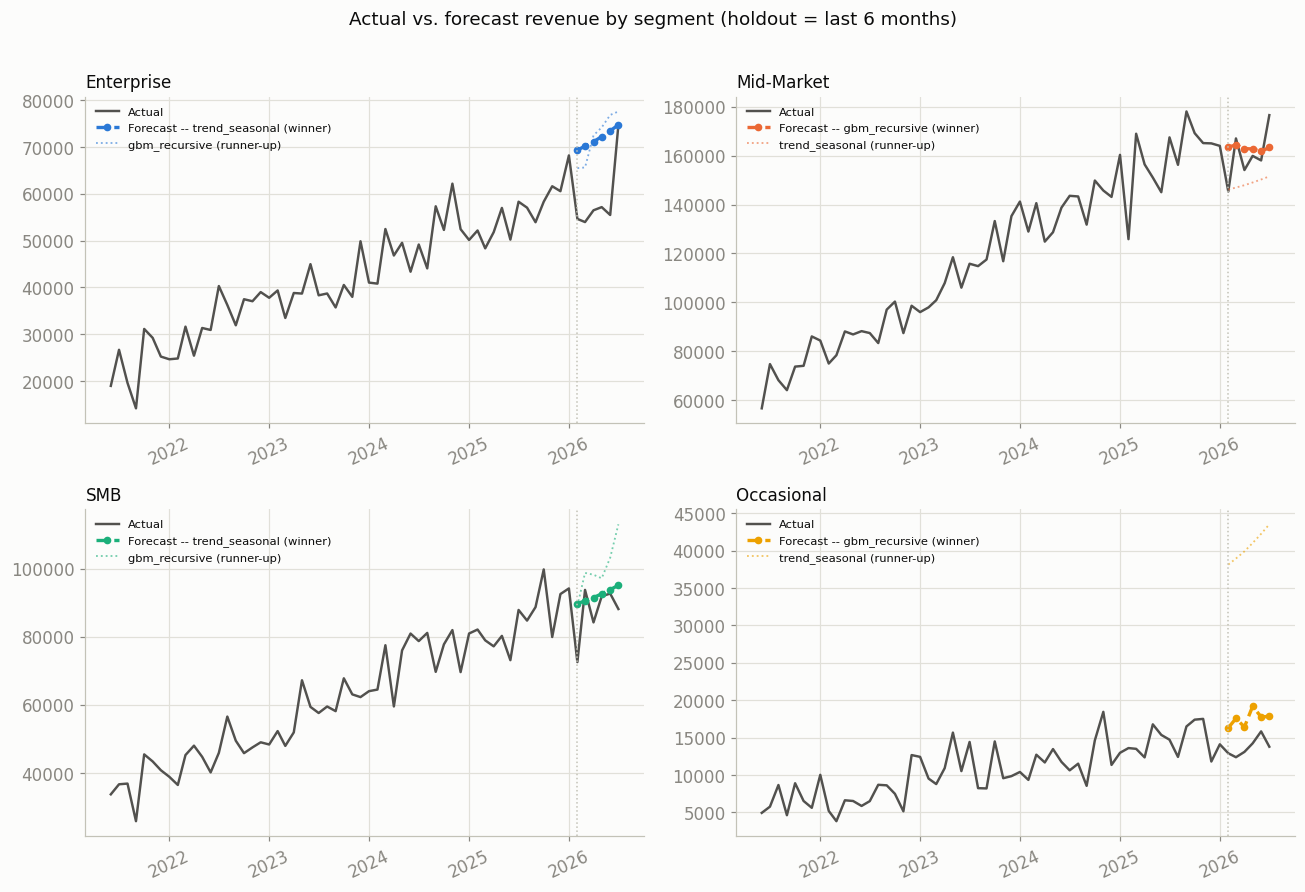

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
for ax, seg, color in zip(axes.flat, SEGMENT_ORDER, CATEGORICAL):
    hist = monthly[monthly["segment"] == seg].sort_values("month")
    e = eval_df[eval_df["segment"] == seg].sort_values("month")
    winner = winner_map[seg]
    other_col = "forecast" if winner == "trend_seasonal" else "trend_forecast"
    other_label = "gbm_recursive" if winner == "trend_seasonal" else "trend_seasonal"
    ax.plot(hist["month"], hist["revenue"], color=INK["secondary"], linewidth=1.6, label="Actual")
    ax.plot(e["month"], e["blended_forecast"], color=color, linewidth=2.2, linestyle="--", marker="o",
            markersize=4, label=f"Forecast -- {winner} (winner)")
    ax.plot(e["month"], e[other_col], color=color, linewidth=1.2, linestyle=":", alpha=0.6,
            label=f"{other_label} (runner-up)")
    ax.axvline(cutoff_month, color=INK["baseline"], linestyle=":", linewidth=1)
    ax.set_title(seg, loc="left", fontsize=11)
    ax.legend(frameon=False, fontsize=7.5)
    ax.tick_params(axis="x", rotation=25)
fig.suptitle("Actual vs. forecast revenue by segment (holdout = last 6 months)", fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "01_forecast_vs_actual.png"), bbox_inches="tight")
plt.show()

## 6. Company-level (bottom-up) forecast

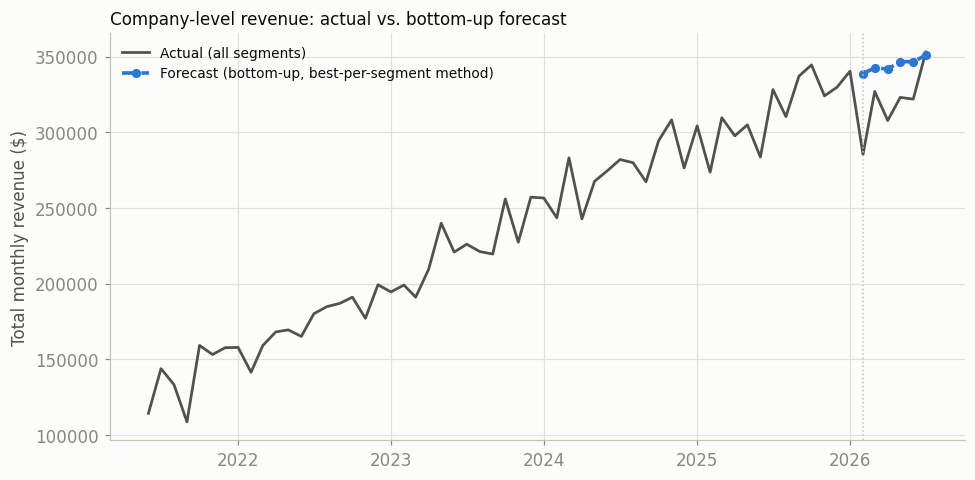

In [9]:
total_actual = monthly.groupby("month")["revenue"].sum().reset_index()
total_forecast = eval_df.groupby("month")["blended_forecast"].sum().reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(total_actual["month"], total_actual["revenue"], color=INK["secondary"], linewidth=1.8, label="Actual (all segments)")
ax.plot(total_forecast["month"], total_forecast["blended_forecast"], color=CATEGORICAL[0], linewidth=2.4,
        linestyle="--", marker="o", markersize=5, label="Forecast (bottom-up, best-per-segment method)")
ax.axvline(cutoff_month, color=INK["baseline"], linestyle=":", linewidth=1)
ax.set_ylabel("Total monthly revenue ($)")
ax.set_title("Company-level revenue: actual vs. bottom-up forecast", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIG_SUBDIR, "02_total_forecast.png"), bbox_inches="tight")
plt.show()

## 7. Refit on full history & forecast 3 months forward

For an actual production hand-off we'd refit both models on all
available data (including the holdout window we just validated on) and
roll the forecast forward past the end of known data -- using whichever
method won each segment's backtest.

In [10]:
full_feat = build_feature_table(monthly)
model_full = Pipeline([("pre", make_preprocessor()), ("reg", HistGradientBoostingRegressor(
    max_depth=3, learning_rate=0.07, max_iter=250, random_state=RANDOM_SEED))])
model_full.fit(full_feat[feature_cols], full_feat["target"])

trend_feat_full = trend_feat.copy()
trend_pipe_full = Pipeline([("pre", make_preprocessor()), ("reg", LinearRegression())])
trend_pipe_full.fit(trend_feat_full[trend_cols], trend_feat_full["revenue"])

FORWARD_MONTHS = 3
future_cutoff = monthly["month"].max() + pd.DateOffset(months=1)
future_gbm = recursive_forecast(monthly, model_full, feature_cols, future_cutoff, FORWARD_MONTHS)

future_rows = []
max_time_idx = trend_feat_full.groupby("segment")["time_idx"].max()
for step in range(FORWARD_MONTHS):
    m = future_cutoff + pd.DateOffset(months=step)
    for seg in SEGMENT_ORDER:
        future_rows.append({
            "segment": seg, "time_idx": max_time_idx[seg] + 1 + step,
            "month_sin": np.sin(2 * np.pi * m.month / 12), "month_cos": np.cos(2 * np.pi * m.month / 12),
            "month": m,
        })
future_trend_X = pd.DataFrame(future_rows)
future_trend_X["trend_forecast"] = trend_pipe_full.predict(future_trend_X[trend_cols])

future_fc = future_gbm.merge(future_trend_X[["segment", "month", "trend_forecast"]], on=["segment", "month"])
future_fc["blended_forecast"] = np.where(
    future_fc["segment"].map(winner_map) == "trend_seasonal", future_fc["trend_forecast"], future_fc["forecast"]
)
print(f"Forward forecast ({FORWARD_MONTHS} months beyond {monthly['month'].max().strftime('%Y-%m')}), best-per-segment method:")
print(future_fc.pivot(index="month", columns="segment", values="blended_forecast").round(0))

Forward forecast (3 months beyond 2026-07), best-per-segment method:
segment     Enterprise  Mid-Market  Occasional      SMB
month                                                  
2026-08-01     73122.0    165115.0     14573.0  94233.0
2026-09-01     74526.0    165115.0     16623.0  95636.0
2026-10-01     75575.0    165327.0     16512.0  96685.0

## 8. Save

In [11]:
eval_df.to_csv(os.path.join(DATA_DIR, "forecast_backtest.csv"), index=False)
future_fc.to_csv(os.path.join(DATA_DIR, "forecast_forward.csv"), index=False)
metrics_df.to_csv(os.path.join(DATA_DIR, "forecast_metrics.csv"), index=False)
print("Saved forecast_backtest.csv, forecast_forward.csv, forecast_metrics.csv")

Saved forecast_backtest.csv, forecast_forward.csv, forecast_metrics.csv